In [1]:
from glob import glob
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
img_paths=sorted(glob("/home/uwr/FLS*/*"))
img_paths

['/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/001.png',
 '/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/002.png',
 '/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/003.png',
 '/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/004.png',
 '/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/005.png',
 '/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/006.png',
 '/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/007.png',
 '/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/008.png',
 '/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/009.png',
 '/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/010.png',
 '/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/011.png',
 '/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/012.png',
 '/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/013.png',
 '/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/014.png',
 '/home/uwr/FLS_UWR_localization_2024_dataset_cleaned/015.png',
 '/home/uwr/FLS_UWR_localization_2024_da

In [37]:
x=[]
y=[]
for i in range(0,len(img_paths)-1,20):
    img=cv2.imread(img_paths[i],0)
    _, binary1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    moments1 = cv2.moments(binary1)
    if moments1['m00'] != 0:
        x.append((moments1['m10'] / moments1['m00']))
        y.append(moments1['m01'] / moments1['m00'])

In [16]:
vx=[]
vy=[]
for i in range(0,len(img_paths)-1,20):
    i1=cv2.imread(img_paths[i],0)
    i2=cv2.imread(img_paths[i+1],0)
    flow = cv2.calcOpticalFlowFarneback(i1, i2, None, 0.5, 3, 15, 3, 5, 1.2, 0)

    # Calculate the average motion (vx, vy) in the region of interest
    vx.append(np.mean(flow[..., 0]))  # Horizontal motion
    vy.append(np.mean(flow[..., 1])) # Vertical motion


In [13]:
x_v=[]
x_v_init=0
for v_val_x in vx:
    x_v_init+=(v_val_x)
    x_v.append(x_v_init)
y_v=[]
y_v_init=0
for v_val_y in vy:
    y_v_init+=(v_val_y)
    y_v.append(y_v_init)

In [ ]:
x_v=np.array(x_v)
y_v=np.array(y_v)

In [39]:
def take_moment(image):
    _,thresh=cv2.threshold(image,127,255,cv2.THRESH_BINARY)
    moments1 = cv2.moments(thresh)
    if moments1['m00'] != 0:
        print((moments1['m10'] / moments1['m00']))
        print(moments1['m01'] / moments1['m00'])

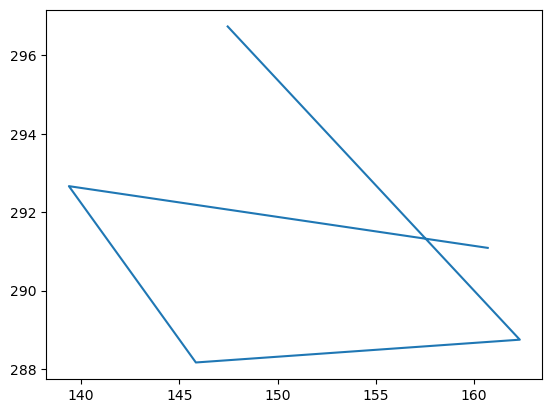

In [38]:
plt.plot(x[5:10],y[5:10])

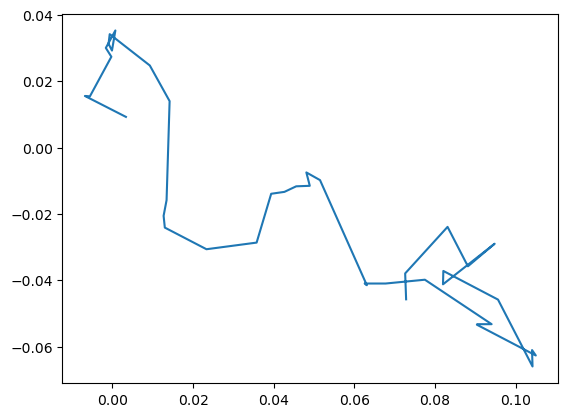

In [18]:
plt.plot(x_v[:],y_v[:])

In [52]:
i1=cv2.imread(img_paths[0],0)
i2=cv2.imread(img_paths[1],0)

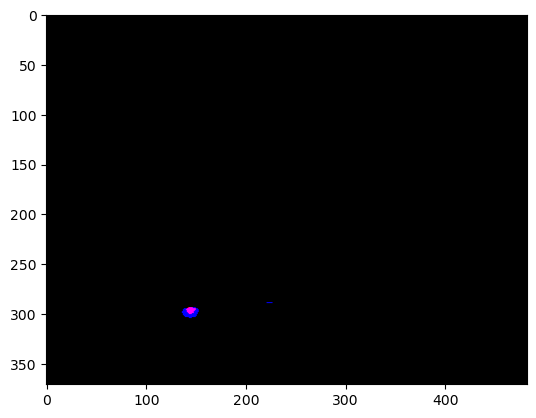

In [53]:
i3=cv2.merge([i1,np.zeros_like(i1),i2])
plt.imshow(i3)

In [54]:
take_moment(i1)

144.4375
296.6875


In [55]:
take_moment(i2)

147.3716216216216
298.27702702702703


In [56]:
flow = cv2.calcOpticalFlowFarneback(i1, i2, None, 0.5, 3, 15, 3, 5, 1.2, 0)

In [57]:
np.mean(flow[..., 0])

0.0033338086

In [58]:
np.mean(flow[..., 1])

0.009231462